### Stage 1: Probability Dropoff

In this notebook we are looking explicitly at the difference in success probability (and its components) between 100 workers and 10 workers. The dropoff is not as much as we expected, so we investigate further.

See notebook: stage_1_probability_components.ipynb for more detailed look at the components functions, including any that do not perform as expected (e.g. creativity cpts in liniear scenario.)

In [147]:
import pandas as pd
import pickle
import numpy as np
from scipy.stats import entropy
from scipy.stats import linregress
import superscript_abm

import matplotlib.pyplot as plt
%matplotlib inline

#### First we look at Greedy results for 100 and 10 workers (filtered using 'first_n').

In [3]:
def load_results(path):
    with open(path, 'rb') as infile:
        results = pickle.load(infile)
        
    return results

In [128]:
results_10_workers = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_greedy_run_0/results.pickle')
results_100_workers = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_greedy_run_0/results.pickle')

In [129]:
# results_10_workers = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_grasp_run_1/results.pickle')
# results_100_workers = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_grasp_run_0/results.pickle')

In [130]:
results_100_workers.keys()

dict_keys(['runtime', 'probability', 'team_size', 'workers', 'state_file', 'timeout', 'ovr', 'skill_balance', 'creativity_match', 'creativity_level', 'risk', 'individual_chemistry', 'team_chemistry', 'probability_ovr', 'probability_skill_balance', 'probability_creativity_match', 'probability_individual_chemistry', 'probability_team_chemistry', 'probability_risk'])

In [131]:
not_to_plot = ['workers', 'state_file', 'timeout']

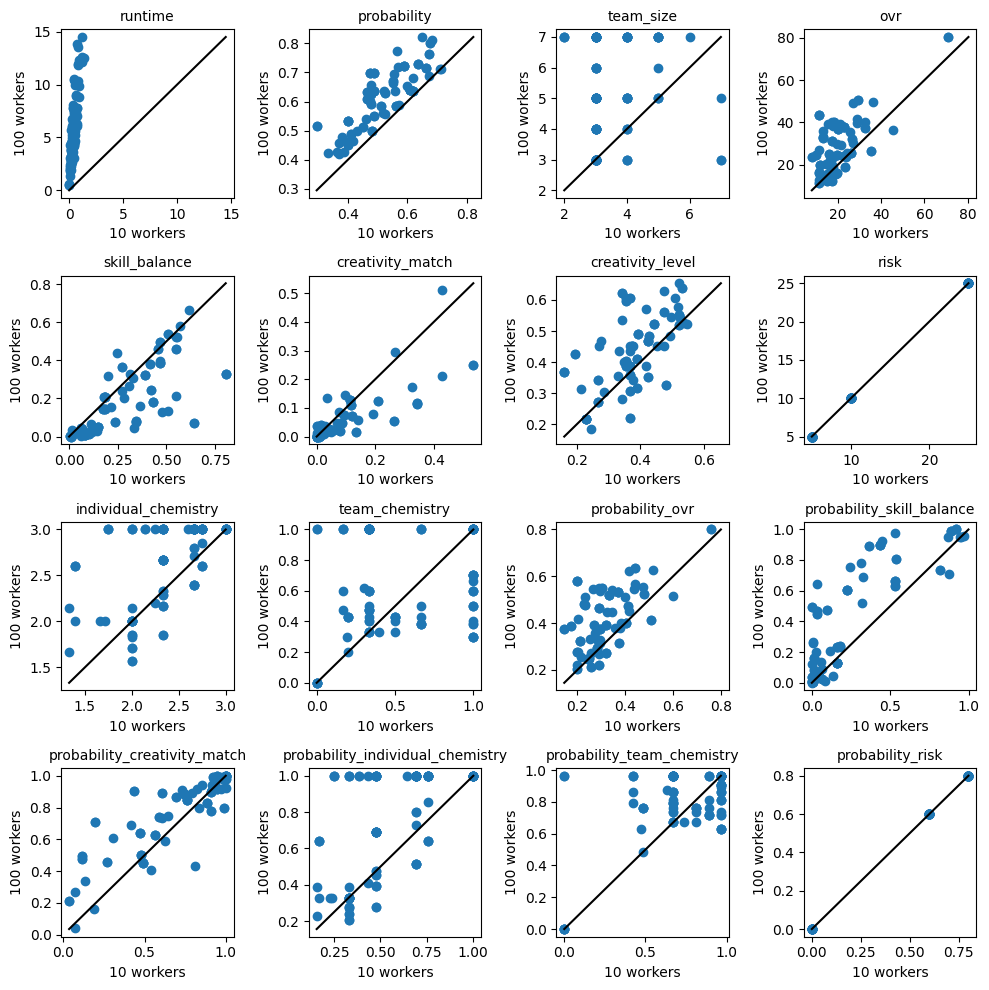

In [132]:
plot_id = 1
plt.figure(figsize=(10,10))
for key in results_100_workers.keys():
    if key not in not_to_plot:
        plt.subplot(4,4,plot_id)
#         print(key)
        
        X = results_10_workers[key]
        Y = results_100_workers[key]
        plt.scatter(X, Y)
        
        _X = [xi for xi in X if xi is not None]
        _Y = [xi for xi in Y if xi is not None]
        x_min = min(_X)
        x_max = max(_X)
        y_min = min(_Y)
        y_max = max(_Y)
        
        mmin = min(x_min, y_min)
        mmax = max(x_max, y_max)
        
        plt.plot([mmin, mmax], [mmin, mmax], c='k')
        plt.xlabel('10 workers')
        plt.ylabel('100 workers')
        plt.title(key, fontsize=10);
        plot_id += 1

plt.tight_layout()

probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk


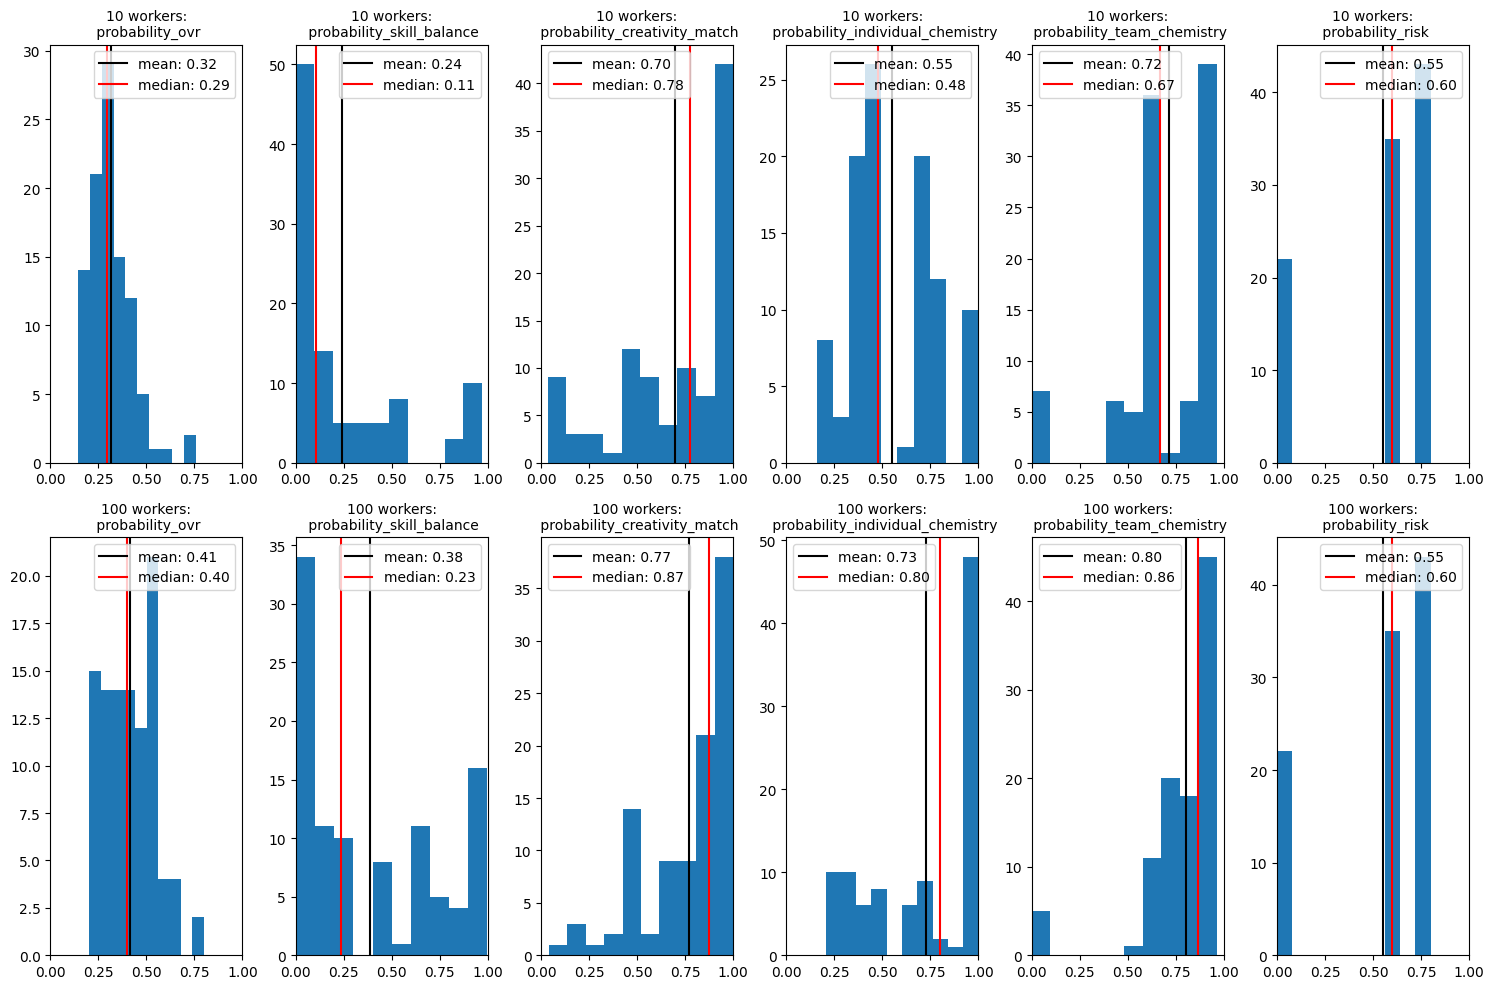

In [133]:
components = []
fs = 10

plot_id = 1
plt.figure(figsize=(15,10))
for key in results_100_workers.keys():
    if 'probability_' in key:
        
        components.append(key[12:])
        print(key)
        plt.subplot(2,6,plot_id)
        X = results_10_workers[key]
        plt.axvline(np.mean(X), c='k', label='mean: %.2f' % np.mean(X))
        plt.axvline(np.median(X), c='r', label='median: %.2f' % np.median(X))
        plt.hist(X)
        plt.xlim([0,1])
        plt.legend()
        plt.title('10 workers:\n %s' % key, fontsize=fs)
        
        plt.subplot(2,6,plot_id+6)
        Y = results_100_workers[key]
        plt.axvline(np.mean(Y), c='k', label='mean: %.2f' % np.mean(Y))
        plt.axvline(np.median(Y), c='r', label='median: %.2f' % np.median(Y))
        plt.xlim([0,1])
        plt.hist(Y)
        plt.legend()
        plt.title('100 workers:\n %s' % key, fontsize=fs)

        plot_id += 1

plt.tight_layout()

#### We now look at the absolute difference between 100 and 10 worker probabilities (and components). 

##### For each componnent of the success probabilitty function, we look for a state-metric that correlates with it, based on how hard that compnents is to optimise for that state.

#### TODO: we also look at tails of distributions?

In [134]:
absolute_difference = {}
relative_difference = {}

for key in results_10_workers.keys():
    if 'probability' in key:
        absolute_difference[key] = [i - j if (i is not None and j is not None) else None for i,j in zip(results_100_workers[key], results_10_workers[key])]
        relative_difference[key] = [(i - j)/i if (i is not None and j is not None and i !=0) else None for i,j in zip(results_100_workers[key], results_10_workers[key])]

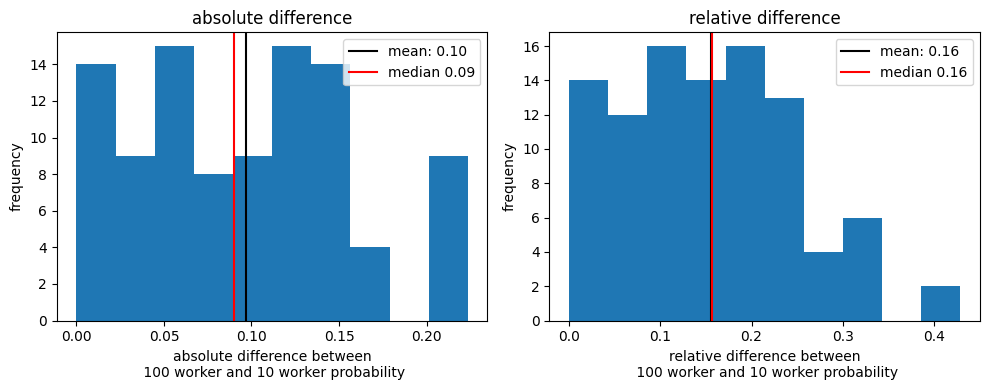

In [135]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
X = [xi for xi in absolute_difference['probability'] if xi is not None]
plt.hist(X);
plt.axvline(np.mean(X), label='mean: %.2f' % np.mean(X), color='k')
plt.axvline(np.median(X), label='median %.2f' % np.median(X), color='r')
plt.legend()
plt.xlabel('absolute difference between\n 100 worker and 10 worker probability')
plt.ylabel('frequency')
plt.title('absolute difference');

plt.subplot(1,2,2)
X = [xi for xi in relative_difference['probability'] if xi is not None]
plt.hist(X);
plt.axvline(np.mean(X), label='mean: %.2f' % np.mean(X), color='k')
plt.axvline(np.median(X), label='median %.2f' % np.median(X), color='r')
plt.legend()
plt.xlabel('relative difference between\n 100 worker and 10 worker probability')
plt.ylabel('frequency')
plt.title('relative difference');
plt.tight_layout();

# print(np.max(X))

#### Here we define the candidate explanatory metrics for each component:

In [136]:
def ovr(hard_skills, ovr_multiplier=20):
    """
    Calculate total workforce ovr.
    """
    return (
        hard_skills.sum(axis=1)
        / (hard_skills > 0.0).sum(axis=1)
    ) * ovr_multiplier

In [137]:
def project_hard_skill_difficulty(state):
    return (state.state['project_skill_levels'] * state.state['project_skill_units']).sum()

def project_required_creativity(state):
    return state.state['project_required_creativity']

# probability_ovr could also be related to project difficulty?
def workforce_average_ovr(state, average=np.mean):
    return average(ovr(state.state['worker_hard_skills']))

# can use as proxy for recen success (inidivudal checmistry?) - otherwise add reent success to state.
def social_network_edge_count(state):
    return state.state['social_network'].sum()

def top_hard_skill_diversity(state):
    worker_count = state.state['worker_hard_skills'].shape[0]
    return entropy(state.state['worker_hard_skills'].argmax(axis=1) / worker_count)

def relative_risk(state):
    return state.state['project_risk'] / workforce_average_ovr(state)

In [138]:
explanatory_metrics = {
    'project_hard_skill_difficulty': [],
    'project_required_creativity': [],
    'workforce_average_ovr': [],
    'social_network_edge_count': [],
    'top_hard_skill_diversity': [],
    'relative_risk': [],
}

for file in results_100_workers['state_file']:
    with open('../test_data/dataset_1/%s' % file, 'rb') as infile:
        state = pickle.load(infile)
    
    for key in explanatory_metrics.keys():
        explanatory_metrics[key].append(
            locals()[key](state)
        )

In [139]:
explanatory_metrics.keys()

dict_keys(['project_hard_skill_difficulty', 'project_required_creativity', 'workforce_average_ovr', 'social_network_edge_count', 'top_hard_skill_diversity', 'relative_risk'])

### Based on hard skill requirements, there is a transition in behaviour between easy and hard projects...

- Very hard projects are often almost impossible to optimise skill_balance for, regardless of number of workers.
- At the lower end of the spectrum, easier projects have the expected trend: more workers gives better probability_skill_balance. However, the trend is not strong.

#### TODO: further investigate these 'difficult' projects that have ~zero probability_skill_balance (and result in low absolute difference between 100 and 10 workers). Specifically:
- do other algorithms do better on these projects? (e.g. GRASP, RLS1)
- do the other components compensate in terms of overall success probability?
- do other projects show a more convincing trend for the easy projects, comparing 10 to 100 workers.
- Look at negative values on top panel: does RL find global optimum.

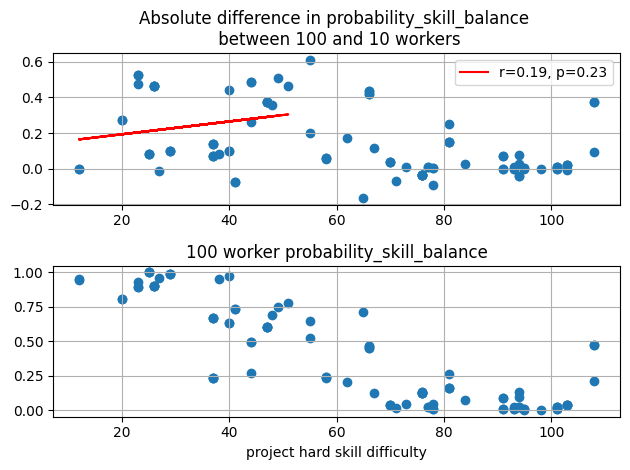

In [157]:
project_difficulties = explanatory_metrics['project_hard_skill_difficulty']

plt.subplot(2,1,1)
x = np.array(project_difficulties)
y = np.array(absolute_difference['probability_skill_balance'])
# y = np.array(relative_difference['probability_skill_balance'])
plt.scatter(x, y)
plt.title('Absolute difference in probability_skill_balance \n between 100 and 10 workers');

easy_cutoff = 55
y = y[x<easy_cutoff]
x = x[x<easy_cutoff]
slope, intercept, r, p, se = linregress(x, y)
plt.plot(x, intercept + slope*x, 'r', label='r=%.2f, p=%.2f' % (r, p))
plt.grid()
plt.legend()

plt.subplot(2,1,2)
plt.scatter(project_difficulties, results_100_workers['probability_skill_balance'])
plt.xlabel('project hard skill difficulty')
plt.title('100 worker probability_skill_balance')
plt.grid()
plt.tight_layout();

### Projects requiring greater creativity are hard, and the difference is greater for 100  workers.

Note: there is also a slight effect where is it difficult to create very uncreative teams, and this is easier with more workers. However at the limit it is impossible to match near-zero creativity with 100 or 10 workers.

##### TODO:  confirms this lower limit behaviour.

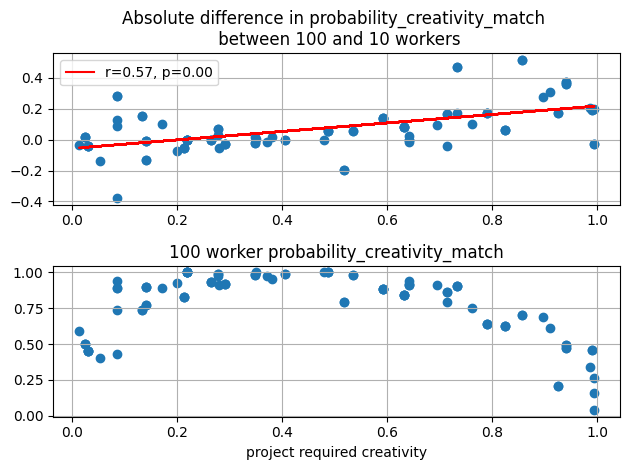

In [158]:
project_difficulties = explanatory_metrics['project_required_creativity']

plt.subplot(2,1,1)
x = np.array(project_difficulties)
y = np.array(absolute_difference['probability_creativity_match'])
# y = np.array(relative_difference['probability_skill_balance'])
plt.scatter(x, y)
plt.title('Absolute difference in probability_creativity_match \n between 100 and 10 workers');

easy_cutoff = 55
y = y[x<easy_cutoff]
x = x[x<easy_cutoff]
slope, intercept, r, p, se = linregress(x, y)
plt.plot(x, intercept + slope*x, 'r', label='r=%.2f, p=%.2f' % (r, p))
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.scatter(project_difficulties, results_100_workers['probability_creativity_match'])
plt.xlabel('project required creativity')
plt.title('100 worker probability_creativity_match')
plt.grid()
plt.tight_layout();

### Harder projects tend to have a slightly lower probability_ovr component. This makes some sense as there is more constraint on which workers you choose. However, it is hard to fine a metric that correlates with the difference between 10 and 100 workers.

#### TODO: investigate probability_ovr component further...

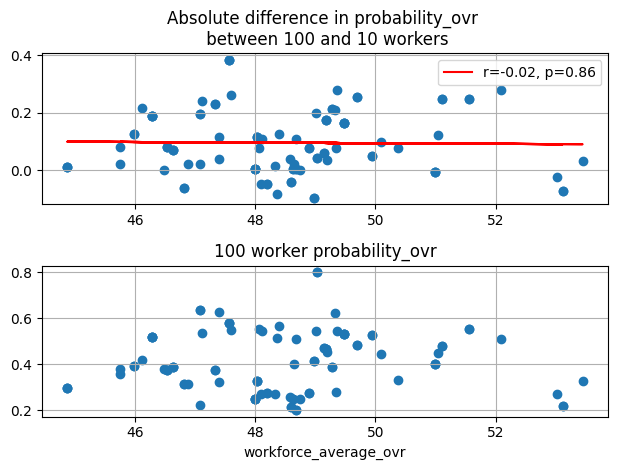

In [182]:
# project_difficulties = explanatory_metrics['workforce_average_ovr']
metric = 'workforce_average_ovr'
# metric = 'project_hard_skill_difficulty'
project_difficulties = explanatory_metrics[metric]

plt.subplot(2,1,1)
x = np.array(project_difficulties)
y = np.array(absolute_difference['probability_ovr'])
# y = np.array(relative_difference['probability_skill_balance'])
plt.scatter(x, y)
plt.title('Absolute difference in probability_ovr \n between 100 and 10 workers');

easy_cutoff = 160
y = y[x<easy_cutoff]
x = x[x<easy_cutoff]
slope, intercept, r, p, se = linregress(x, y)
plt.plot(x, intercept + slope*x, 'r', label='r=%.2f, p=%.2f' % (r, p))
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.scatter(project_difficulties, results_100_workers['probability_ovr'])
plt.xlabel(metric)
plt.title('100 worker probability_ovr')
plt.grid()
plt.tight_layout();

### The more highly connected the network, the higher the probability_team_chemistry component. There is a weak trend that we might expect - networks with fewer edges are easier to solve with 100 rather than 10 workers. But overall it seems that it is too easy to have a good team chemistry?

#### TODO: perhaps make team chemistry harder to acheive?

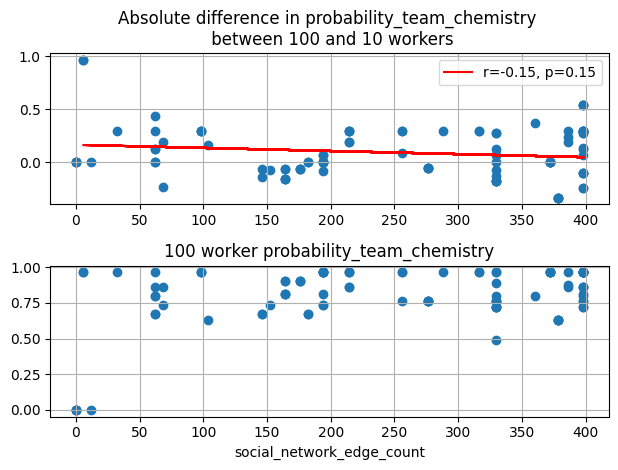

In [173]:
# project_difficulties = explanatory_metrics['workforce_average_ovr']
metric = 'social_network_edge_count'
project_difficulties = explanatory_metrics[metric]

plt.subplot(2,1,1)
x = np.array(project_difficulties)
y = np.array(absolute_difference['probability_team_chemistry'])
# y = np.array(relative_difference['probability_skill_balance'])
plt.scatter(x, y)
plt.title('Absolute difference in probability_team_chemistry \n between 100 and 10 workers');

lower_cutoff = 0
easy_cutoff = 400
y = y[x<easy_cutoff]
x = x[x<easy_cutoff]

y = y[x>lower_cutoff]
x = x[x>lower_cutoff]

slope, intercept, r, p, se = linregress(x, y)
plt.plot(x, intercept + slope*x, 'r', label='r=%.2f, p=%.2f' % (r, p))
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.scatter(project_difficulties, results_100_workers['probability_team_chemistry'])
plt.xlabel(metric)
plt.title('100 worker probability_team_chemistry')
plt.grid()
plt.tight_layout();

In [174]:
absolute_difference.keys()

dict_keys(['probability', 'probability_ovr', 'probability_skill_balance', 'probability_creativity_match', 'probability_individual_chemistry', 'probability_team_chemistry', 'probability_risk'])

### Top hard skill diversity has good explanatory power for predicting absolute difference between 100 and 10 workers. But relative risk does not, although it does explain probability_individual_chemistry.

#### TODO: investigate further...

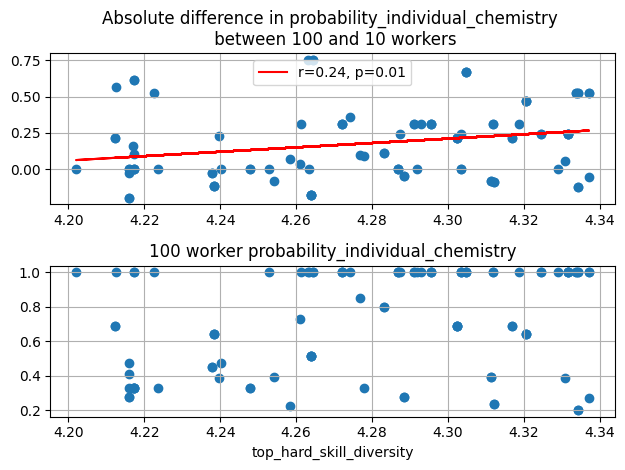

In [183]:
# metric = 'relative_risk'
metric = 'top_hard_skill_diversity'
# metric = ??momentum cpts??

project_difficulties = explanatory_metrics[metric]

plt.subplot(2,1,1)
x = np.array(project_difficulties)
y = np.array(absolute_difference['probability_individual_chemistry'])
# y = np.array(relative_difference['probability_skill_balance'])
plt.scatter(x, y)
plt.title('Absolute difference in probability_individual_chemistry \n between 100 and 10 workers');

lower_cutoff = 0
easy_cutoff = 400
y = y[x<easy_cutoff]
x = x[x<easy_cutoff]

y = y[x>lower_cutoff]
x = x[x>lower_cutoff]

slope, intercept, r, p, se = linregress(x, y)
plt.plot(x, intercept + slope*x, 'r', label='r=%.2f, p=%.2f' % (r, p))
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.scatter(project_difficulties, results_100_workers['probability_individual_chemistry'])
plt.xlabel(metric)
plt.title('100 worker probability_individual_chemistry')
plt.grid()
plt.tight_layout();

#### Look across components - does 'hard' project perform well on other cpts?